In [1]:
# Python module useful for measuring the time and time differences
import time
# Sys provides access to some variables used or maintained by the interpreter and to functions that interact strongly with the interpreter.
import sys
# Os is useful when you want to do something with the operating system
import os
# Package with support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
# Main part of our lecture.
import numpy as np
# Package for optimization, linear algebra, integration, interpolation, special functions, fast Fourier transform, signal and image processing
import scipy

## What happens above? (Python modules, system packages, etc)
The modules time and sys are already part of the [Python standard library](https://docs.python.org/3/library/index.html), that means they are preinstalled when you install Python.
In contrast, numpy and scipy are external third-party packages for scientific computing. They are distributed via a Python Package index called [Pypi](https://pypi.org/), where everybody can upload their Python code. For you the numpy and scipy package should be already pre-installed.

All of these packages contain Python code which is loaded when you import it and that can then be used by you.
How does Python find this code? It looks at the following places (e.g. see these [slides](https://d3s.mff.cuni.cz/f/teaching/nprg065/2026/python-lecture-04.pdf) for a longer explanation):
- In the current directory/folder.
- In the directories that are defined in the variable PYTHONPATH.
- In installation defaults.

Let's find out about those:

In [2]:
print("Current directory:", os.getcwd())
print("Content of PYTHONPATH:", os.getenv("PYTHONPATH"))
print("Installation defaults:", sys.path)

Current directory: /home/jovyan/work/__shared/10 - Numpy and Scipy
Content of PYTHONPATH: None
Installation defaults: ['/opt/conda/lib/python312.zip', '/opt/conda/lib/python3.12', '/opt/conda/lib/python3.12/lib-dynload', '', '/opt/conda/lib/python3.12/site-packages']


You can also check for each of the imported modules where the code of these files is located (disclaimer: this does not work if the module was written in a different programming language that got compiled).
You can do that by looking at the `__file__` attribute of the imported packages. Python uses special attributes and functions that start and end with `__` to expose internal information and behavior.

In [3]:
print("Location of the code of the package os:", os.__file__)
print("Location of the code of the package numpy:", np.__file__)

Location of the code of the package os: /opt/conda/lib/python3.12/os.py
Location of the code of the package numpy: /opt/conda/lib/python3.12/site-packages/numpy/__init__.py


## Write your own module (single Python file) and package (multiple Python files)

To do this, let us first talk about (recap?) how to write a python function.

A function is a reusable block of code that performs a specific task. Functions are defined using the def keyword:

In [4]:
def greet(name):
    greeting = "Hello " + name
    return greeting

Above function is called `greet` and has one argument `name`. You can call this function with a string and print the result:

In [5]:
x = greet("Python Class")
print(x)

Hello Python Class


### TASK: Create your own Python Module (3 Minutes)
A Python module is a text file with a filename that ends in `.py`. Your task is to create the file `my_module.py` (do this using "right-click" and then click on "New File").

In this file write the following functions (do as many of these as you want):
- `def greet(name)`: The function from above (you can copy it)
- `def add_numbers_until(x)`: adds up all numbers from 0 to x and returns the result. x should be an integer (e.g. `42`).
- `def filter_positive_numbers(numbers)`: returns a new list containing only positive numbers. numbers should be a list of integers (e.g. `[-2, 0, 2]`).
- `def count_characters(text, character)`: counts how often a character appears in a string. Text should be a string (e.g. "test") and character a single character (e.g. "t").
- Your own function.

In [6]:
import my_module

In [7]:
# Test if we were successful
print(my_module.greet("hello"))
print(my_module.add_numbers_until(10))
print(my_module.filter_positive_numbers([-2, 0, 10, -132, 1000]))

Hello hello
55
[[-2, 0, 10, -132, 1000], [-2, 0, 10, -132, 1000]]


### TASK: Create your own Python Package (3 Minutes)
A Python package is a directory (folder) that contains multiple Python modules (.py files). Packages help organize larger projects into multiple files.

Your task is to create the following folder structure:
```
my_package/
│
├── __init__.py
├── math_functions.py
└── text_functions.py
```
Steps:

Create a new folder called my_package ("right click" and then select "New Folder") 
Inside the folder, create the files:
- `__init__.py`: Can stay empty. Its purpose is to tell Python that this folder should be treated as a package.
- `math_functions.py`: Copy the math functions `add_numbers_until` and `filter_positive_numbers` in there.
- `text_functions.py`: Copy the text functions `greet` and `count_characters` in there.


In [8]:
import my_package.math_functions
import my_package.text_functions

In [9]:
print(my_package.math_functions.add_numbers_until(10))
print(my_package.text_functions.greet("World"))
my_package.math_functions.filter_positive_numbers("sdffdsafds")

55
Hello World


[]

## Numpy
Now that we know how to write our own package, let us look at the [NumPy](https://numpy.org/doc/stable/) package somebody else already wrote for us.
See [here](https://numpy.org/doc/2.4/user/absolute_beginners.html) for a more extensive beginners guide.

One main part of NumPy is to create arrays of numbers. These are similar to Python lists, but they are optimized for numerical calculations, are usually faster, and they can have multiple dimensions.

In [10]:
python_list = [1, 2, "sdffdsafdsa", 4]
numpy_array = np.array([1, 2, 3, 4])

python_list_of_lists = [[1, 2, 3, 4], [5, 6, 7]]
numpy_array_2d = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])

In [11]:
numpy_array_2d

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

You can access the NumPy array similarly to how you access Python lists, e.g.:

In [12]:
print("a[0]:", numpy_array[0])
print("a[-1]:", numpy_array[-1])
print("a[1:-1]:", numpy_array[1:-1])
print("a_2d[1][2:4]:", numpy_array_2d[1][2:4])
print("a_2d[1, 2:4]:", numpy_array_2d[1, 2:4])

a[0]: 1
a[-1]: 4
a[1:-1]: [2 3]
a_2d[1][2:4]: [7 8]
a_2d[1, 2:4]: [7 8]


In [13]:
numpy_array_2d[0, 2:4]

array([3, 4])

Each numpy arrays has the following attributes:
- ndim: Dimensions of the array, e.g. 2
- shape: Shape of the array, e.g. (4, 2)
- dtype: Type of each element of the array, e.g. int64 or float16

In [14]:
print("ndim a_2d:", numpy_array_2d.ndim)
print("shape a_2d:", numpy_array_2d.shape)
print("dtype a_2d:", numpy_array_2d.dtype)

ndim a_2d: 2
shape a_2d: (2, 4)
dtype a_2d: int64


In [15]:
np.linspace(2, 10, 100)

array([ 2.        ,  2.08080808,  2.16161616,  2.24242424,  2.32323232,
        2.4040404 ,  2.48484848,  2.56565657,  2.64646465,  2.72727273,
        2.80808081,  2.88888889,  2.96969697,  3.05050505,  3.13131313,
        3.21212121,  3.29292929,  3.37373737,  3.45454545,  3.53535354,
        3.61616162,  3.6969697 ,  3.77777778,  3.85858586,  3.93939394,
        4.02020202,  4.1010101 ,  4.18181818,  4.26262626,  4.34343434,
        4.42424242,  4.50505051,  4.58585859,  4.66666667,  4.74747475,
        4.82828283,  4.90909091,  4.98989899,  5.07070707,  5.15151515,
        5.23232323,  5.31313131,  5.39393939,  5.47474747,  5.55555556,
        5.63636364,  5.71717172,  5.7979798 ,  5.87878788,  5.95959596,
        6.04040404,  6.12121212,  6.2020202 ,  6.28282828,  6.36363636,
        6.44444444,  6.52525253,  6.60606061,  6.68686869,  6.76767677,
        6.84848485,  6.92929293,  7.01010101,  7.09090909,  7.17171717,
        7.25252525,  7.33333333,  7.41414141,  7.49494949,  7.57

The following options are convenient to create new arrays:
- np.zeros(), np.ones(), np.empty(): just pass the shape of the array you want to create, e.g. `np.ones((11, 17))`. You can always specify the dtype, e.g. `np.ones((11, 17), dtype="int32")`
- np.arange(): creates an array with evenly spaced values in a given interval, similar to Python's range(), e.g. `np.arange(0, 10, 2)` creates `array([0, 2, 4, 6, 8])`
- np.linspace(): creates an array with a fixed number of evenly spaced values between a start and end point, e.g. `np.linspace(0, 1, 5)` creates `array([0. , 0.25, 0.5 , 0.75, 1. ])`

You can also apply mathematical operations on these arrays and combine them in various ways (be aware, the shapes of the arrays have to match):

In [16]:
ones = np.ones((2, 3))
twos = np.ones((2, 3)) + np.ones((2, 3))
twos_v2 = np.zeros((2, 3)) + 2
twos_v3 = np.ones((2, 3)) * 2
# NumPy broadcasts the shape (3,) across the first dimension so it behaves like a (2, 3) array here.
twos_v4 = np.ones((2, 3)) + np.ones((3))

In [17]:
twos

array([[2., 2., 2.],
       [2., 2., 2.]])

In [18]:
try:
    # Be aware: the shapes have to match
    twos_failure = np.ones((2, 3)) + np.ones((2, 5))

except ValueError as e:
    print("Error:", e)

Error: operands could not be broadcast together with shapes (2,3) (2,5) 


### TASK: Compare the speed of using Python lists to using NumPy arrays

One advantage of NumPy is that it is fast, because it uses optimized code that is tailored to operations on its arrays. We want to compare how much faster NumPy is than using loops in Python. For this write two Python functions that take either a list of numbers or a NumPy arrays of numbers:
- `def sum_list_elements(lst)`: Sum all elements in the list using a for loop in Python
- `def sum_numpy_elements(ar)`: Sum all elements in the array using numpy (e.g. by using `np.sum(ar)` or `ar.sum()`

After doing this, you can call the function with inputs of different sizes and measure their time. I suggest doing something like:
```
num_elements = 10
your_list = list(range(num_elements))
start_time_list = time.time()
res_list = sum_list_elements(your_list)
total_time_list = time.time() - start_time_list

your_array = np.arange(num_elements)
start_time_np = time.time()
result_np = sum_numpy_elements(your_array)
total_time_np = time.time() - start_time_np

print("Timings: ", total_time_list, total_time_np)
```

Do this for different array sizes, e.g. for arrays with ten, one thousand, one million elements.


In [19]:
def sum_list_elements(lst):
    return sum(lst)

def sum_numpy_elements(ar):
    return ar.sum()


num_elements = 100_000_000
your_list = list(range(num_elements))
start_time_list = time.time()
res_list = sum_list_elements(your_list)
total_time_list = time.time() - start_time_list

your_array = np.arange(num_elements)
start_time_np = time.time()
result_np = sum_numpy_elements(your_array)
total_time_np = time.time() - start_time_np

print(f"Timings, python list: {total_time_list:.5f}s, NumPy array: {total_time_np:.5f}s")

Timings, python list: 0.89492s, NumPy array: 0.08875s


Note: Using NumPy, we can add 100 million numbers in under 100ms, that is more than a billion additions per second.
The computer above ran on is a Intel(R) Xeon(R) Gold 6248 CPU @ 2.50GHz (use `lscpu` in the bash console to see yourself), which means it can execute about 2.5 billion operations per second.
While Python was an order of magnitude slower, with NumPy we already got above one billion additions per second.

## Interlude: Another Interface to the Computer, the Command Line

The command line is a textual, rather than graphical, interface to your computer. It's useful for multiple reasons:
- You need a basic understanding if you work on a computing cluster
- It is a direct way to interact with your computer and files
- AI coding agents like Claude or GPT frequently use the command line
- You use it when installing packages, or to run tests, and CI things

You access the command line in our interface in the launcher window (click the blue `+` on the top left) by clicking on "Bash". You can either choose the "Notebook" version or the console version. This will give you a Linux command line. If you try it on your own computer it will be very similar if you use a MacBook, but on Windows the commands will be different.

Here's a tutorial that might be helpful: [Linux Command Line for Beginners](https://ubuntu.com/tutorials/command-line-for-beginners#1-overview).
To summarize some useful commands:
- hostname: show the name of the computer/server (hostname)
- pwd: print the current working directory (pwd)
- ls: list files and folders (ls)
- cd: change directory (cd my_folder)
- mkdir: create a new directory (mkdir data)
- touch: create an empty file (touch notes.txt)
- cp: copy files or folders (cp file.txt backup.txt)
- mv: move or rename files (mv old.txt new.txt)
- rm: remove files (rm file.txt)
- cat: print the content of a file (cat notes.txt)
- head: show the first lines of a file (head data.csv)
- tail: show the last lines of a file (tail data.csv)
- grep: search for text patterns in files (grep "error" log.txt)

You can always type a command in combination with `--help` (e.g., `pwd --help`) to see information about the command.

### Task: Use the Command Line to Explore NumPy Code (3 min)
As you have learned, the code of NumPy is also present on your computer. You can find its location using `np.__file__`.
Use `cd` to go to the directory of the NumPy code, explore which files are present (`ls`) and look at a few files (`head`, `tail`, or `cat`).

In [20]:
np.__file__

'/opt/conda/lib/python3.12/site-packages/numpy/__init__.py'

In [21]:
!ls /opt/conda/lib/python3.12/site-packages/numpy/

__config__.py		_globals.py	   doc		   polynomial
__init__.cython-30.pxd	_pyinstaller	   dtypes.py	   py.typed
__init__.pxd		_pytesttester.py   dtypes.pyi	   random
__init__.py		_pytesttester.pyi  exceptions.py   rec
__init__.pyi		_typing		   exceptions.pyi  strings
__pycache__		_utils		   f2py		   testing
_array_api_info.py	char		   fft		   tests
_array_api_info.pyi	compat		   lib		   typing
_configtool.py		conftest.py	   linalg	   version.py
_core			core		   ma		   version.pyi
_distributor_init.py	ctypeslib.py	   matlib.py
_expired_attrs_2_0.py	ctypeslib.pyi	   matrixlib


In [22]:
!head /opt/conda/lib/python3.12/site-packages/numpy/__init__.py

"""
NumPy
=====

Provides
  1. An array object of arbitrary homogeneous items
  2. Fast mathematical operations over arrays
  3. Linear Algebra, Fourier Transforms, Random Number Generation

How to use the documentation


### Task: Use the Command Line to Estimate the Size of Different dtypes
It's also possible to save NumPy arrays as a file on your computer. This works as follows in your Jupyter notebook:
```
ar = np.ones((100, 100), dtype="float")
np.save("np_array.npy", ar)
```

Try this for different dtypes (e.g., "bool", "int8", "float", "int", "double", "float64"). Check the size of the resulting files in your command line using `ls -l` and `ls -lh` (e.g., `ls -lh np_array.npy`).
Can you find out how many bytes of storage each element of these data types consumes?

In [23]:
# Let's do a million (1000 * 1000) elements, this makes the calculation easier.
ar_float = np.ones((1000, 1000), dtype="float")  # float
np.save("np_array_float.npy", ar_float)
ar_bool = np.ones((1000, 1000), dtype="bool")  # boolean
np.save("np_array_bool.npy", ar_bool)
ar_int32 = np.ones((1000, 1000), dtype="int32")  # integer with 32 bit
np.save("np_array_int32.npy", ar_int32)

Note: You can also access the terminal directly from the Jupyter notebook by writing `!` at the beginning of a code cell:

In [24]:
!ls -l .

total 13653
drwxr-xr-x 2 jovyan root      43 May 15 14:00 __pycache__
-rw-r--r-- 1 jovyan root     318 May 15 13:59 my_module.py
drwxr-xr-x 4 jovyan root     164 May 15 12:57 my_package
-rw-r--r-- 1 jovyan root 1000128 May 15 14:27 np_array_bool.npy
-rw-r--r-- 1 jovyan root 8000128 May 15 14:27 np_array_float.npy
-rw-r--r-- 1 jovyan root 4000128 May 15 14:27 np_array_int32.npy
-rw-r--r-- 1 jovyan root  454821 May 15 14:26 numpy_scipy-solution.ipynb
-rw-r--r-- 1 jovyan root   21254 May 15 10:55 numpy_scipy.ipynb


The fifth row with the numbers shows the size of each file in bytes. One byte consists of 8 bits. Computers store information using bits, which are represented as 0s and 1s.

The boolean array has a size of 1,000,128 bytes, the float array 8,000,128 bytes, and the integer array 4,000,128 bytes. This suggests that NumPy stores an additional 128 bytes of metadata for each array.

To estimate how much memory each element uses, we can divide the total size (excluding the small metadata overhead) by 1 million elements:

- Each element in the boolean array uses 1 byte (= 8 bits)
- Each element in the float array uses 8 bytes (= 64 bits, which is why the type is called float64, use `ar_float.dtype` to check)
- Each element in the int32 array uses 4 bytes (= 32 bits, which is why the type is called int32)

## SciPy: Scientific Algorithms Built on NumPy (3 min)

SciPy is a Python package built on top of NumPy that provides many scientific algorithms and numerical methods.

It contains functionality for statistics, signal processing, linear algebra, differential equations, and much more.
As an example, we will use it to process and image using 2-dimensional convolutions.
For a good visual explanation of convolutions, I recommend [this 3Blue1Brown Youtube video](https://www.youtube.com/watch?v=KuXjwB4LzSA).


Shape: (512, 512) Dtype: uint8


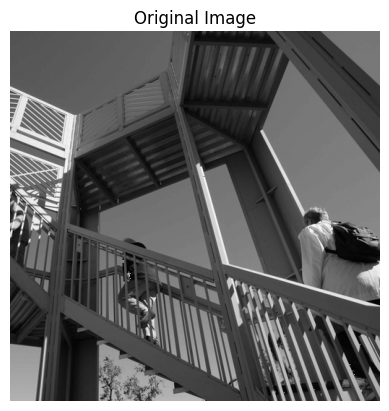

In [25]:
import scipy.signal
import matplotlib.pyplot as plt

image = scipy.datasets.ascent()
print("Shape:", image.shape, "Dtype:", image.dtype)

plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

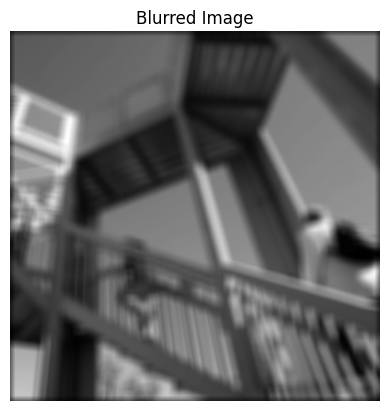

In [26]:
# Create a 15x15 filter filled with ones
kernel = np.ones((15, 15))
# Normalize filter
kernel = kernel / np.abs(kernel).sum()

# Apply convolution
filtered_image = scipy.signal.convolve2d(
    image,
    kernel,
    mode="same"
)

plt.imshow(filtered_image, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")
plt.show()

### TASK: Edit the kernel used in the Convolution and see how the image changes
What happens if you change the kernel of the convolution?
You can use a smaller or bigger shaped kernel, or a kernel that is a combination of minus ones and ones (tip: `np.stack([-np.ones((5)), np.ones((5))])` creates this.
Any other interesting kernels you can think of? If you need inspiration, [Wikipedia describes](https://en.wikipedia.org/wiki/Receptive_field#Retinal_ganglion_cells) the receptive field of retinal ganglion cells as center surround like.

#### Bonus Task [Conway's Game Of Life](https://en.wikipedia.org/wiki/Conway%27s_Game_of_Life)
Think of the world in Conway's Game of Life as a two dimensional boolean array (i.e. each element is 1 or 0).
How can you use a convolution to "count" the direct neighbors of each pixel?
Is it possible to implement the Game of Life completely in NumPy with the help of convolutions? 
Do you get the same results compared to implementing it in pure Python? How does the speed differ?

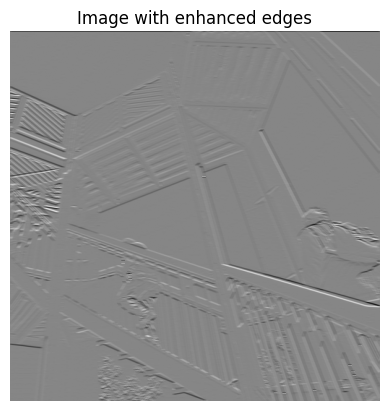

In [28]:
# Some edge enhancing kernel (you can also reimplement the filters in the Youtube video if you want to)
kernel = np.stack([-np.ones((5)), np.ones((5))])

# Apply convolution
filtered_image = scipy.signal.convolve2d(
    image,
    kernel,
    mode="same"
)

plt.imshow(filtered_image, cmap="gray")
plt.title("Image with enhanced edges")
plt.axis("off")
plt.show()